In [1]:
import jax
import jax.numpy as jnp
import jax.random as jrandom

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from functools import partial

import haiku as hk # DeepMind's neural network library
import optax # Gradient-based optimization in JAX

from probjax.utils.odeint import odeint
from probjax.nn.transformers import Transformer
from probjax.nn.helpers import GaussianFourierEmbedding
from probjax.nn.loss_fn import denoising_score_matching_loss
from probjax.distributions.sde import VPSDE, VESDE
from probjax.distributions import Empirical, Independent

from scoresbibm.src.utils.plot import use_style

from sbi.analysis import pairplot
import numpy as np

In [2]:
from sbi.utils import posterior_nn
import torch
num_params = 0
for param in posterior_nn("nsf", hidden_features=100)(torch.ones((1000, 10)), torch.ones(1000,10)).parameters():
    num_params += param.flatten().shape[0]
num_params

294775

In [160]:
from scoresbibm.src.tasks import LinearGaussian, MixtureGaussian, TwoMoons, SLCP, NonlinearGaussianTreeAllConditionalTask, NonlinearMarcovChainAllConditionalTask

In [161]:
task1 = LinearGaussian(backend="jax")
task2 = MixtureGaussian(backend="jax")
task3 = TwoMoons(backend="jax")
task4 = SLCP(backend="jax")
task5 = NonlinearGaussianTreeAllConditionalTask(backend="jax")
task6 = NonlinearMarcovChainAllConditionalTask(backend="jax")

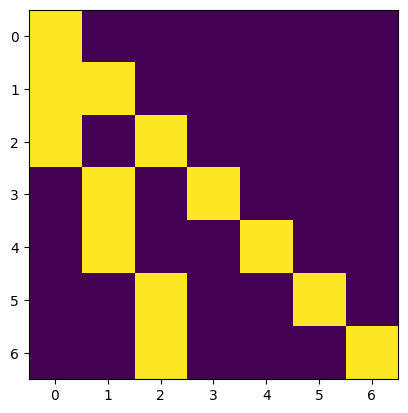

In [162]:
plt.imshow(task5.get_base_mask_fn()(task5.get_node_id(), None))

In [165]:
gaussian_linear_mask = task1.get_base_mask_fn()(task1.get_node_id(), None)
slcp_mask = task4.get_base_mask_fn()(task4.get_node_id(), None)
tree_mask = task5.get_base_mask_fn()(task5.get_node_id(), None)
hmm_mask = task6.get_base_mask_fn()(task6.get_node_id(), None)

In [159]:
jnp.linalg.det(gaussian_linear_mask + gaussian_linear_mask.T)

Array(0., dtype=float32)

In [3]:
# Arrays will always land on the device first in the list.
# Device handling is automatic, depending for which device the function is compiled or where the data is placed.
jax.devices()

[cuda(id=0)]

In [4]:
# Set random key
key = jax.random.PRNGKey(0)

In [10]:
def connected_by_path_of_length_n(edge_mask, n):
    for _ in range(n):
        edge_mask = jnp.matmul(edge_mask, edge_mask)
    
    return edge_mask > 0

In [209]:
markovian = jnp.eye(100) + jnp.eye(100, k=-1)
parameter_iid = jnp.block([[jnp.eye(100), jnp.zeros((100, 100))], [jnp.eye(100), markovian]])

In [198]:
with jax.default_device(jax.devices("cpu")[0]):
    print(jnp.linalg.eigvalsh(parameter_iid))

[0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5
 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5
 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5
 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5
 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5
 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5
 1.5 1.5]


In [210]:
parameter_iid_undirected = parameter_iid + parameter_iid.T

In [211]:
connected_by_path_of_length_n(parameter_iid_undirected, 9)

Array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]], dtype=bool)

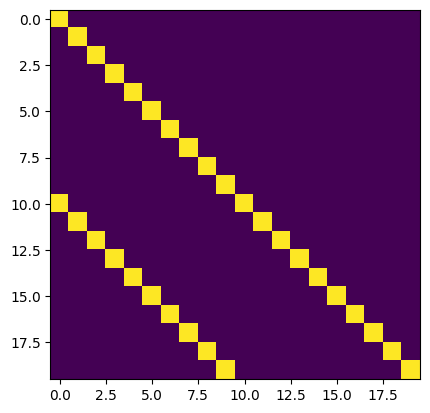

In [229]:
plt.imshow(connected_by_path_of_length_n(gaussian_linear_mask, 50), vmin=0., vmax=1.)

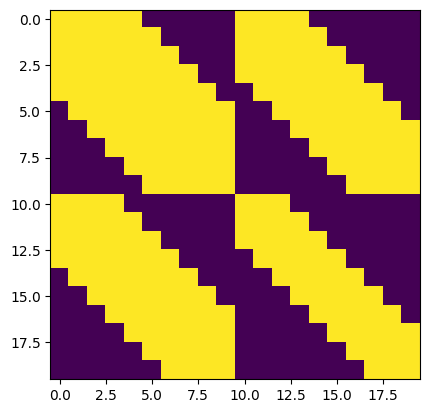

In [227]:
plt.imshow(connected_by_path_of_length_n(hmm_mask + hmm_mask.T, 2))